# Experimento 2 - Transfer learning com *feature extraction* (freeze=10)

Projeto: **Detecção de Faces para Anonimização de Imagens** (conformidade com a LGPD) - disciplina de Introdução à Ciência de Dados e Aprendizado de Máquina (IFSC).

Neste experimento treinamos o YOLO11n no subset do WIDER Face **congelando as primeiras 10 camadas** da rede (`freeze=10`): o *backbone* convolucional, pré-treinado no COCO, é mantido fixo como **extrator de características**, e apenas as camadas finais (o bloco de atenção C2PSA e a cabeça de detecção) são ajustadas para a tarefa de detectar rostos.

Intuição: as primeiras camadas de uma rede convolucional aprendem padrões genéricos (bordas, texturas, formas) que transferem bem entre tarefas; as camadas finais é que precisam se especializar na nova classe.

> **Colab:** selecione GPU (T4) em *Ambiente de execução → Alterar o tipo de ambiente de execução*. O treino de 20 épocas leva em torno de 30–60 minutos.

## 1. Instalação das dependências

O Colab já traz OpenCV, Matplotlib e Pandas pré-instalados; instalamos apenas a biblioteca `ultralytics` (YOLO11) e confirmamos a versão e a disponibilidade de GPU. A checagem é feita diretamente com `torch.cuda.is_available()` - o utilitário `ultralytics.checks()` dispara subprocessos de inspeção do ambiente que podem travar em algumas máquinas.

In [1]:
%pip install -q "ultralytics>=8.3.0"

import torch
import ultralytics

print('ultralytics', ultralytics.__version__)
print('GPU disponivel:', torch.cuda.is_available())

Note: you may need to restart the kernel to use updated packages.
ultralytics 8.4.65
GPU disponivel: True


## 2. Parâmetros

- Os parâmetros do dataset (`TRAIN_SIZE`, `VAL_FRACTION`, `TEST_SIZE`, `SEED`) devem ser **idênticos aos do notebook 01** para que a comparação seja justa.
- `EPOCHS = 20` define o orçamento de treino - o mesmo do experimento 3, para que a comparação entre as estratégias seja feita com custo igual.
- `FREEZE = 10` congela os módulos 0–9 da rede (o backbone convolucional até o SPPF).
- `BATCH = 8` e `WORKERS = 2` limitam o uso de memória durante o treino - a explicação está na seção 4.

In [2]:
import sys
from pathlib import Path

EM_COLAB = 'google.colab' in sys.modules

REPO_URL = 'https://github.com/ifsc-sj-projetos-ia/corrige-aqui'

if EM_COLAB:
    BASE_DIR = Path('/content/projeto-faces')
elif Path.cwd().name == 'notebooks':
    BASE_DIR = Path.cwd().parent
else:
    BASE_DIR = Path.cwd()

NOME_EXPERIMENTO = 'exp2_feature_extraction'
TRAIN_SIZE = 1500
VAL_FRACTION = 0.2
TEST_SIZE = 300
SEED = 42
IMGSZ = 640
EPOCHS = 20
FREEZE = 10
BATCH = 8
WORKERS = 2
CONF_VISUALIZACAO = 0.25

## 3. Obtenção e preparação do dataset

Mesmo procedimento do notebook 01: clone do repositório e execução de `src/prepare_dataset.py` (download do WIDER Face, conversão das anotações para o formato YOLO e geração dos splits). Com a mesma `SEED`, o subset gerado é **exatamente o mesmo** dos outros notebooks.

In [3]:
if EM_COLAB and not BASE_DIR.exists():
    !git clone "{REPO_URL}" "{BASE_DIR}"

DATA_DIR = BASE_DIR / 'data'
SUBSET_DIR = DATA_DIR / 'wider_subset'
DATASET_YAML = SUBSET_DIR / 'dataset.yaml'
SCRIPT_PREPARO = BASE_DIR / 'src' / 'prepare_dataset.py'

if not DATASET_YAML.exists():
    !"{sys.executable}" "{SCRIPT_PREPARO}" --data-dir "{DATA_DIR}" --train-size {TRAIN_SIZE} --val-fraction {VAL_FRACTION} --test-size {TEST_SIZE} --seed {SEED}

## 4. Treinamento

Pontos importantes para entender o que acontece nesta célula:

- Como o `dataset.yaml` declara apenas 1 classe, a Ultralytics **substitui automaticamente a saída da cabeça de detecção** (80 classes do COCO → 1 classe `face`), reaproveitando todos os demais pesos pré-treinados.
- `freeze=10` congela os módulos 0–9 (backbone): esses pesos não recebem gradiente e permanecem como saíram do pré-treino no COCO.
- O conjunto de **validação** é avaliado ao fim de cada época e usado para selecionar o melhor checkpoint (`best.pt`). O conjunto de **teste** fica reservado para a avaliação final.
- A Ultralytics aplica *data augmentation* padrão durante o treino (mosaic, espelhamento horizontal, variações de cor), o que ajuda a reduzir overfitting.
- `batch=8` e `workers=2` controlam o uso de memória. A memória do alinhador de alvos (TaskAlignedAssigner) cresce com `batch × nº máximo de faces por imagem × nº de anchors`, e o *mosaic* combina 4 imagens em uma - cenas de multidão do WIDER Face estouram a memória com o batch padrão (16). Pelo mesmo motivo, o `prepare_dataset.py` exclui imagens com mais de 80 faces (`--max-faces`).
- `seed=SEED` torna o treino reprodutível.

Os artefatos do treino (pesos, curvas, logs) são salvos em `models/exp2_feature_extraction/`.

In [4]:
from ultralytics import YOLO

modelo = YOLO('yolo11n.pt')
resultado_treino = modelo.train(
    data=str(DATASET_YAML),
    epochs=EPOCHS,
    freeze=FREEZE,
    imgsz=IMGSZ,
    batch=BATCH,
    workers=WORKERS,
    seed=SEED,
    project=str(BASE_DIR / 'models'),
    name=NOME_EXPERIMENTO,
    exist_ok=True,
)

Ultralytics 8.4.65  Python-3.14.3 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Davi\corrige-aqui\data\wider_subset\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp2_feature_extraction, nbs=64, nms=False, opset=None, optimize=

## 5. Curvas de treinamento

O arquivo `results.png` mostra as perdas (treino e validação) e as métricas a cada época. Para a discussão de **overfitting** no relatório: se a perda de treino continua caindo enquanto a de validação estabiliza ou sobe, o modelo está decorando o conjunto de treino em vez de generalizar. Com o backbone congelado, a capacidade efetiva da rede é menor e o overfitting tende a ser mais contido.

As figuras ficam em `models/` (pasta não versionada) - copie para `docs/` as que for usar no relatório.

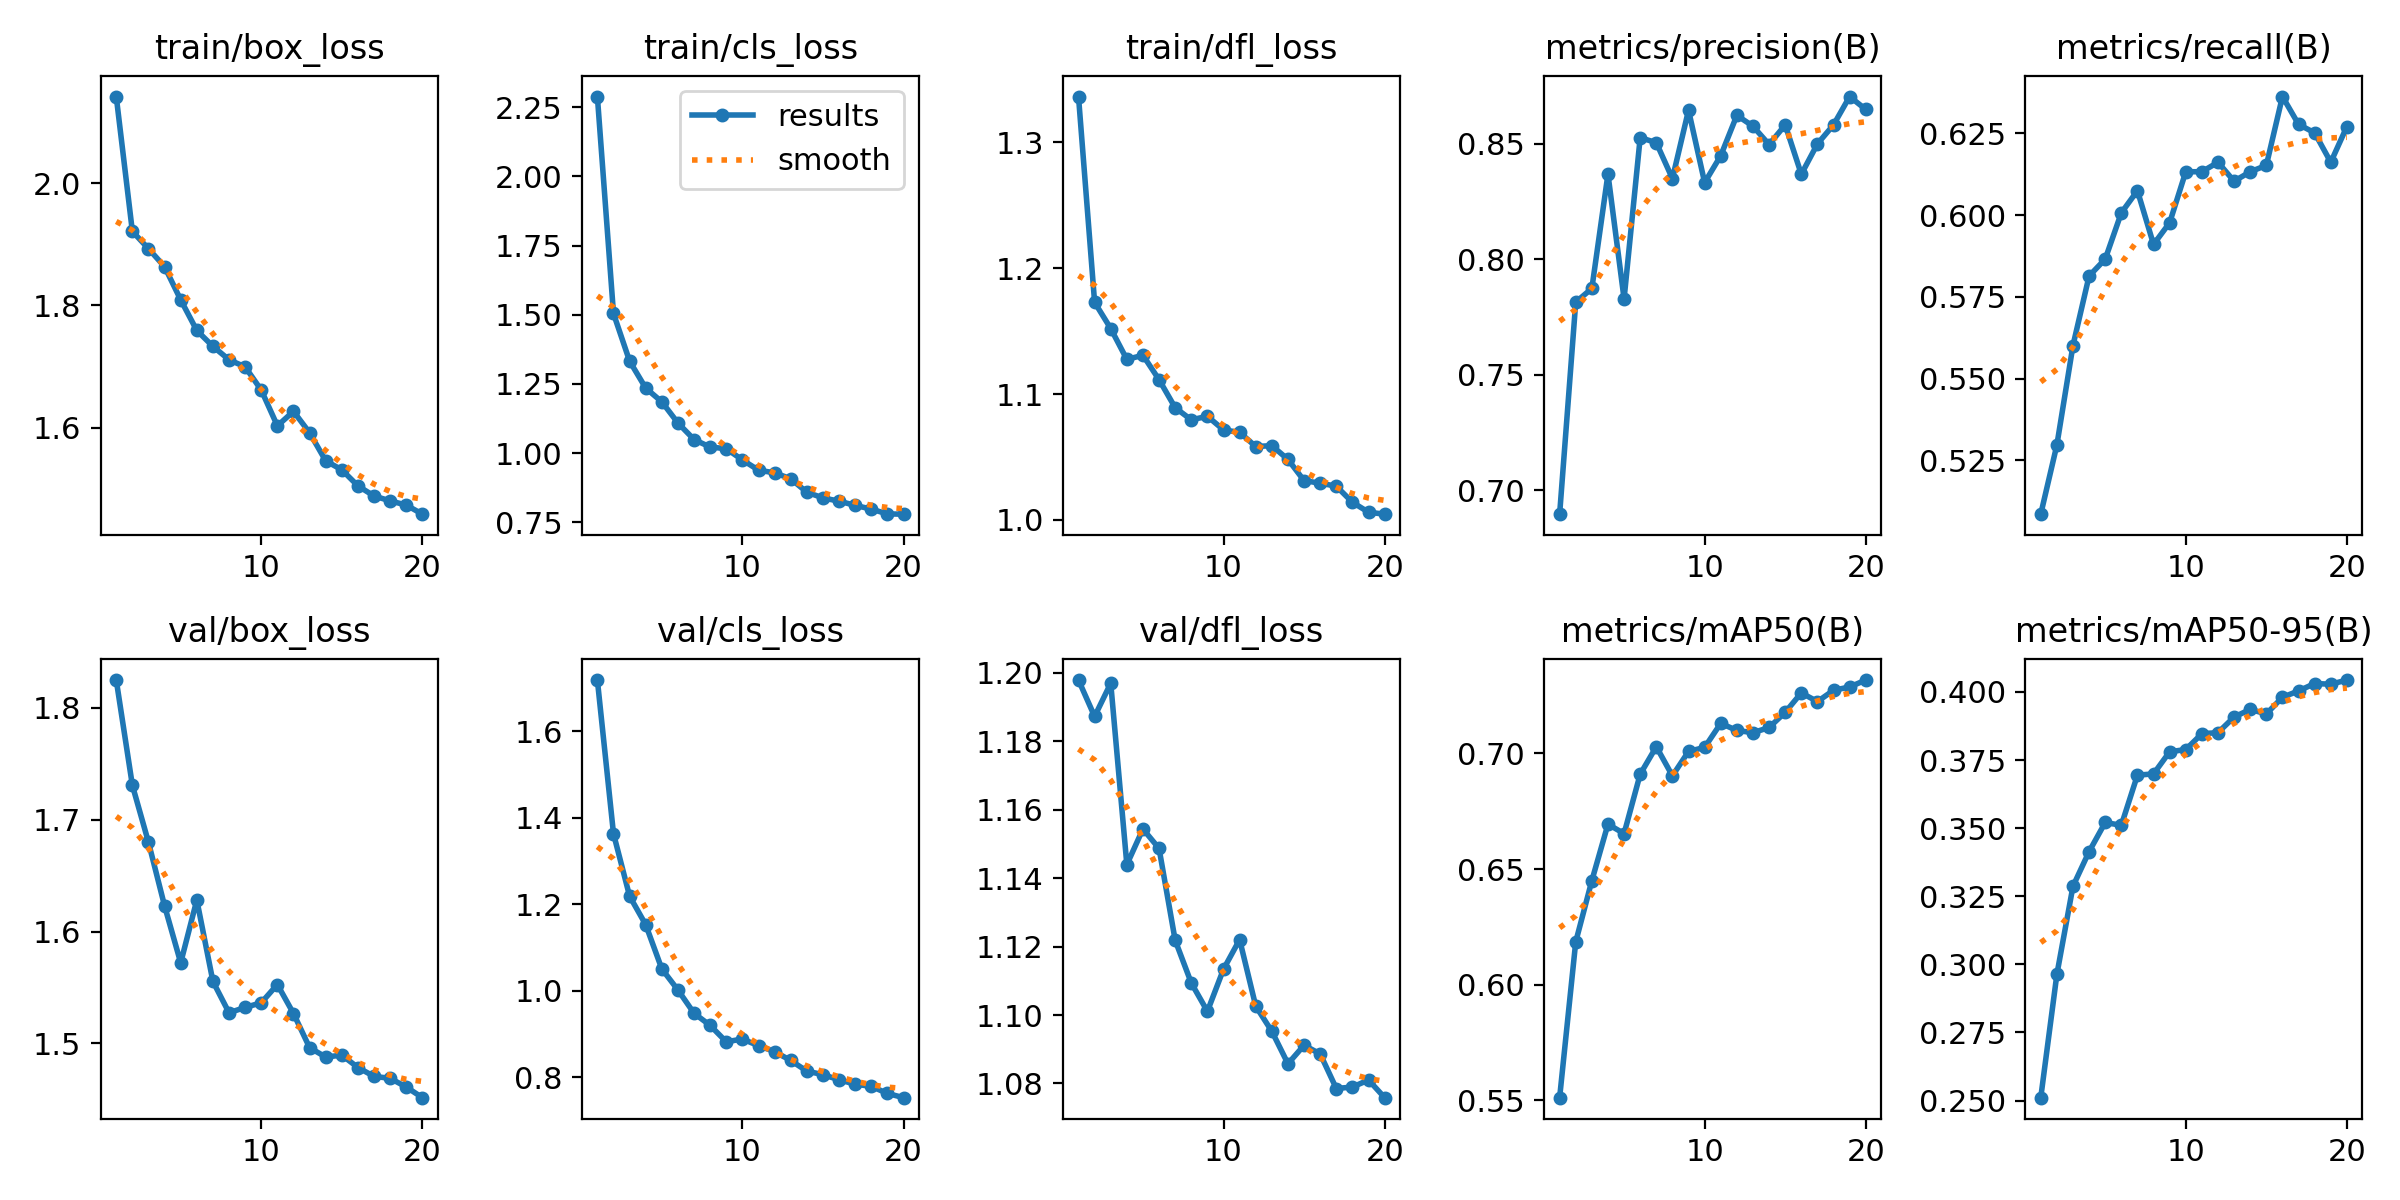

In [5]:
from IPython.display import Image as ExibirImagem

DIR_TREINO = BASE_DIR / 'models' / NOME_EXPERIMENTO
ExibirImagem(filename=str(DIR_TREINO / 'results.png'))

## 6. Avaliação final no conjunto de teste

Carregamos o melhor checkpoint (`best.pt`, escolhido pelo desempenho na validação) e avaliamos no conjunto de **teste**, que o modelo nunca viu - nem para treinar, nem para selecionar checkpoint. É essa a estimativa honesta de generalização que vai para a tabela comparativa.

In [6]:
CAMINHO_MELHOR = DIR_TREINO / 'weights' / 'best.pt'
melhor_modelo = YOLO(str(CAMINHO_MELHOR))

resultados_teste = melhor_modelo.val(
    data=str(DATASET_YAML),
    split='test',
    imgsz=IMGSZ,
    plots=True,
    project=str(BASE_DIR / 'models'),
    name=f'val_{NOME_EXPERIMENTO}',
    exist_ok=True,
)

Ultralytics 8.4.65  Python-3.14.3 torch-2.12.0+cu132 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 150.639.9 MB/s, size: 74.1 KB)
val: Scanning C:\Users\Davi\corrige-aqui\data\wider_subset\test\labels.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 89.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.7it/s 5.1s0.2s
                   all        300       1993      0.843      0.631       0.71      0.399
Speed: 4.6ms preprocess, 6.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to C:\Users\Davi\corrige-aqui\models\val_exp2_feature_extraction


## 7. Registro das métricas

Acrescentamos a linha deste experimento ao `results/metrics.csv`.

In [7]:
import pandas as pd
from datetime import datetime

CSV_METRICAS = BASE_DIR / 'results' / 'metrics.csv'

metricas = {
    'mAP50': round(float(resultados_teste.box.map50), 4),
    'mAP50_95': round(float(resultados_teste.box.map), 4),
    'precision': round(float(resultados_teste.box.mp), 4),
    'recall': round(float(resultados_teste.box.mr), 4),
    'epochs': EPOCHS,
}

def salvar_metricas(nome_experimento, metricas, caminho_csv):
    linha = {'experimento': nome_experimento, **metricas, 'data_hora': datetime.now().isoformat(timespec='seconds')}
    caminho_csv.parent.mkdir(parents=True, exist_ok=True)
    if caminho_csv.exists():
        tabela = pd.read_csv(caminho_csv)
        tabela = tabela[tabela['experimento'] != nome_experimento]
        tabela = pd.concat([tabela, pd.DataFrame([linha])], ignore_index=True)
    else:
        tabela = pd.DataFrame([linha])
    tabela.to_csv(caminho_csv, index=False)
    return tabela

salvar_metricas(NOME_EXPERIMENTO, metricas, CSV_METRICAS)

,experimento,mAP50,mAP50_95,precision,recall,epochs,data_hora
0,exp1_baseline_pretreinado,0.0009,0.0001,0.0054,0.0522,0,2026-06-11T10:51:54
1,exp2_feature_extraction,0.7101,0.3987,0.8426,0.6312,20,2026-06-11T11:01:28


## 8. Análise qualitativa

Agora as caixas devem envolver **rostos**, e não corpos inteiros. Compare visualmente com as imagens do notebook 01 e observe quais rostos ainda escapam (muito pequenos, ocluídos, de perfil) - material para a seção de limitações do relatório.

In [ ]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

imagens_teste = sorted((SUBSET_DIR / 'test' / 'images').glob('*.jpg'))[:6]
predicoes = melhor_modelo.predict([str(p) for p in imagens_teste], conf=CONF_VISUALIZACAO, verbose=False)

figura, eixos = plt.subplots(2, 3, figsize=(16, 9))
for eixo, predicao in zip(eixos.flat, predicoes):
    eixo.imshow(cv2.cvtColor(predicao.plot(), cv2.COLOR_BGR2RGB))
    eixo.axis('off')
figura.tight_layout()
plt.show()

## 9. Download dos resultados (Colab)

Baixe o `metrics.csv` (commitado em `results/`) e o `best.pt` (~5 MB). A pasta `models/` é ignorada pelo git e apenas os pesos do modelo final do projeto são versionados, em `models/best.pt`; guarde os deste experimento no Drive ou localmente para reutilizar sem retreinar.

In [9]:
if EM_COLAB:
    from google.colab import files
    files.download(str(CSV_METRICAS))
    files.download(str(CAMINHO_MELHOR))

## Conclusões do experimento

Pontos para discutir no relatório:

1. Quanto o mAP@0,5 melhorou em relação ao baseline do notebook 01?
2. O recall alcançado é aceitável para um sistema de anonimização? Que tipos de rosto ainda escapam?
3. As curvas de treinamento mostram sinais de overfitting, ou o congelamento do backbone o conteve?
4. Guarde estas curvas para comparar com o experimento 3 (fine-tuning completo): mesma quantidade de épocas, estratégias diferentes.